## Graph dari data paper

### install library

In [ ]:
!pip install PyMuPDF networkx nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 32.6 MB/s eta 0:00:00


### import & stopword setup

In [ ]:
import fitz  # PyMuPDF
import nltk
import re
import networkx as nx
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download("punkt")
nltk.download("stopwords")

stop_words = set(stopwords.words("indonesian"))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### upload

In [ ]:
from google.colab import files
uploaded = files.upload()

pdf_name = list(uploaded.keys())[0]

Saving analisis jejaring sosial.pdf to analisis jejaring sosial.pdf


### ekstrasi teks dari pdf

In [ ]:
doc = fitz.open(pdf_name)
text = ""

for page in doc:
    text += page.get_text()

print("Teks berhasil diekstrak. Panjang:", len(text))

Teks berhasil diekstrak. Panjang: 25087


### ekstrak kalimat

In [ ]:
nltk.download("punkt_tab")
sentences = sent_tokenize(text)
print("Jumlah kalimat:", len(sentences))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Jumlah kalimat: 181


### preprocessing teks

In [ ]:
clean_sentences = []
for sent in sentences:
    sent = sent.lower()
    sent = re.sub(r"[^a-zA-Z\s]", " ", sent)
    tokens = word_tokenize(sent)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    clean_sentences.append(tokens)

clean_sentences[:3]

[['analisis',
  'jejaring',
  'sosial',
  'social',
  'network',
  'analysis',
  'membantu',
  'social',
  'crm',
  'umkm',
  'cimahi',
  'social',
  'network',
  'analysis',
  'using',
  'social',
  'network',
  'analysis',
  'help',
  'social',
  'crm',
  'for',
  'msmes',
  'cimahi',
  'asep',
  'hadiana',
  'wina',
  'witanti',
  'jurusan',
  'informatika',
  'fmipa',
  'universitas',
  'jenderal',
  'achmad',
  'yani',
  'jalan',
  'terusan',
  'jenderal',
  'sudirman',
  'cimahi',
  'email',
  'ahadiana',
  'gmail',
  'com',
  'abstrak',
  'customer',
  'relationship',
  'management',
  'crm',
  'strategi',
  'organisasi',
  'berusaha',
  'meningkatkan',
  'kepuasan',
  'loyalitas',
  'pelanggan',
  'menawarkan',
  'layanan',
  'terbaik',
  'pelanggan'],
 ['organisasi', 'menyadari', 'crm', 'terbantu', 'media', 'sosial'],
 ['social',
  'crm',
  'perluasan',
  'crm',
  'mengintegrasikan',
  'media',
  'sosial',
  'crm']]

### ambil kata unik

In [ ]:
vocab = sorted(list({word for sent in clean_sentences for word in sent}))
vocab_index = {word: i for i, word in enumerate(vocab)}

V = len(vocab)
print("Jumlah kata unik:", V)

Jumlah kata unik: 691


### buat matriks frekuensi dan 0/1

In [ ]:
window_size = 2

# Matriks frekuensi
co_freq = np.zeros((V, V), dtype=int)

for sent in clean_sentences:
    for i, word in enumerate(sent):
        w1 = vocab_index[word]

        # cek kata dalam window size
        for j in range(max(0, i - window_size), min(len(sent), i + window_size + 1)):
            if i == j:
                continue
            w2 = vocab_index[sent[j]]
            co_freq[w1][w2] += 1

# Matriks 0/1 (adjacency)
co_binary = (co_freq > 0).astype(int)

co_binary[:10, :10]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

### tampilkan matriks

In [ ]:
df_binary = pd.DataFrame(co_binary, index=vocab, columns=vocab)
df_freq = pd.DataFrame(co_freq, index=vocab, columns=vocab)

print("Matriks BINARY (0/1):")
df_binary.head()

print("Matriks FREKUENSI:")
df_freq.head()

Matriks BINARY (0/1):
Matriks FREKUENSI:


,abstract,abstrak,achieving,achmad,actor,actors,agndhkaaaaa,ahadiana,akademik,aktivitas,...,with,wonwurd,woodcock,yanchun,yani,york,youtube,zaman,zhang,zhao
abstract,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abstrak,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
achieving,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
achmad,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,0,0,0,0
actor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### word graph dari matriks frekuensi

In [ ]:
G = nx.DiGraph()

for i in range(V):
    for j in range(V):
        if co_freq[i][j] > 0:
            G.add_edge(vocab[i], vocab[j], weight=co_freq[i][j])

print("Node:", G.number_of_nodes())
print("Edge:", G.number_of_edges())

Node: 687
Edge: 4511


### menghitung pagerank

In [ ]:
pagerank_scores = nx.pagerank(G, weight="weight")
sorted_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)

print("=== TOP 20 PAGE RANK ===")
for w, s in sorted_pr[:20]:
    print(f"{w:20s} → {s:.6f}")

=== TOP 20 PAGE RANK ===
sosial               → 0.025526
social               → 0.017926
media                → 0.017161
crm                  → 0.016699
network              → 0.012354
hubungan             → 0.012156
pelanggan            → 0.011576
the                  → 0.010064
analysis             → 0.010010
aktor                → 0.009860
usaha                → 0.008707
interaksi            → 0.008576
and                  → 0.008311
penelitian           → 0.008207
data                 → 0.008008
informasi            → 0.007411
organisasi           → 0.007159
perusahaan           → 0.007089
umkm                 → 0.006759
pola                 → 0.005786


### simpan hasil

In [ ]:
import csv

with open("pagerank_output.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["kata", "pagerank"])
    for w, s in sorted_pr:
        writer.writerow([w, s])

files.download("pagerank_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### visualisasi

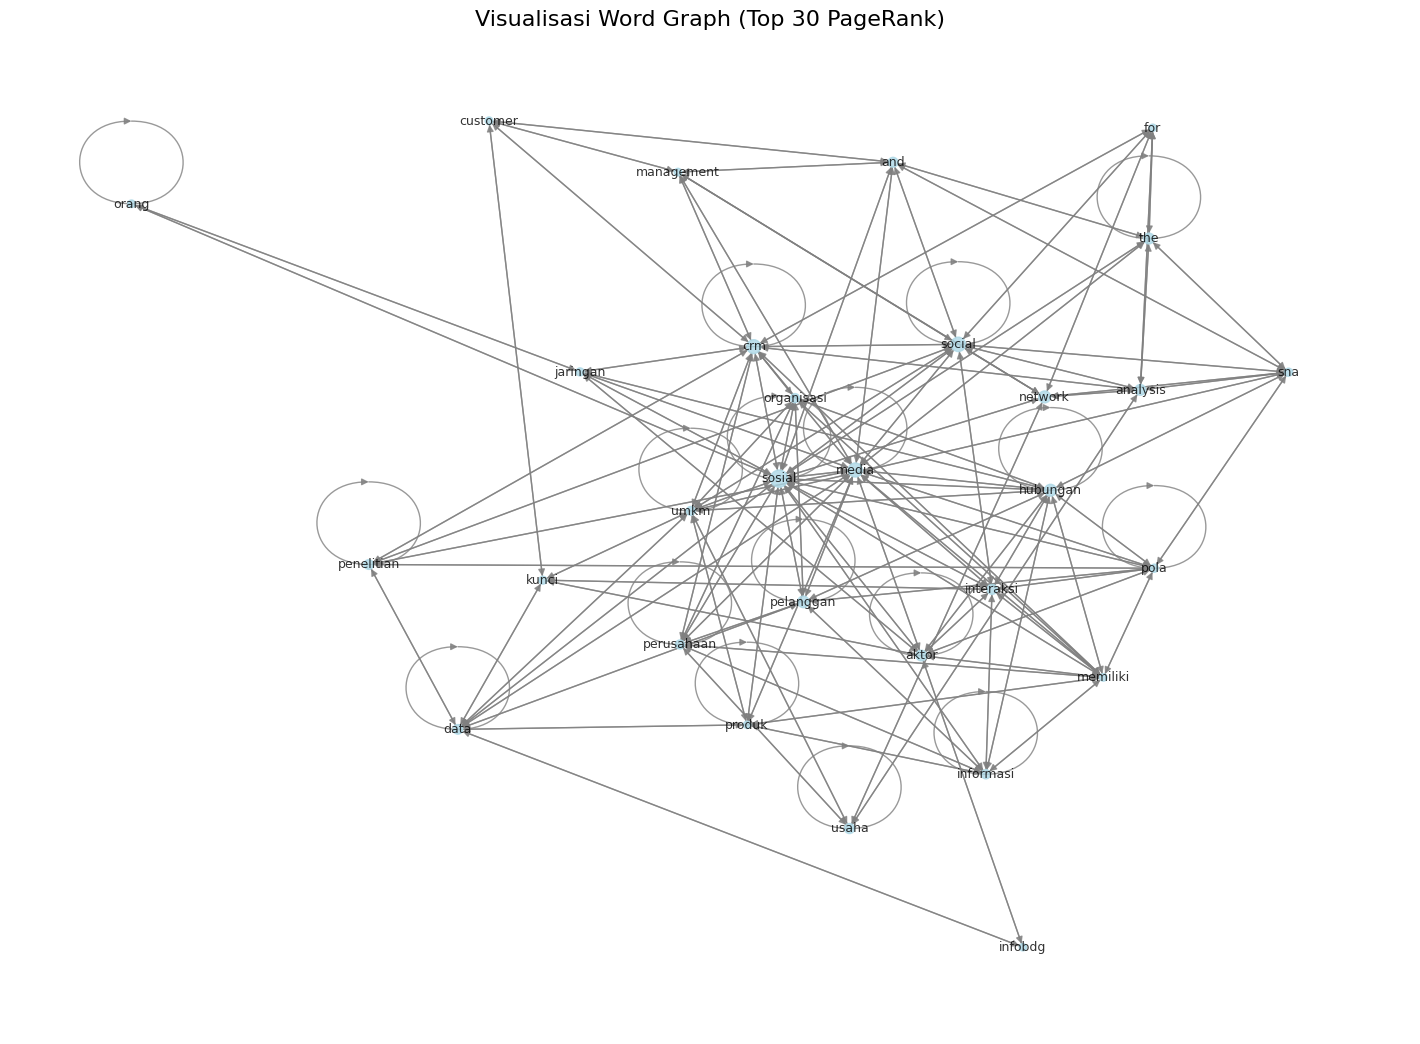

In [ ]:
import matplotlib.pyplot as plt

top_words = [w for w, s in sorted_pr[:30]]
subG = G.subgraph(top_words)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subG, k=0.4)

nx.draw(
    subG,
    pos,
    with_labels=True,
    node_size=[pagerank_scores[w] * 6000 for w in subG.nodes()],
    node_color="lightblue",
    edge_color="gray",
    alpha=0.8,
    font_size=9
)

plt.title("Visualisasi Word Graph (Top 30 PageRank)", fontsize=16)
plt.show()